## 預訓練模型

In [ ]:
from keras.applications.inception_v3 import InceptionV3
model = InceptionV3(weights='imagenet', include_top=True)

96124928/96112376 [==============================] - 0s 0us/step


In [ ]:
model.summary()

Model: "inception_v3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 299, 299, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 149, 149, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 149, 149, 32  96         ['conv2d[0][0]']                 
 alization)                     )                                                      

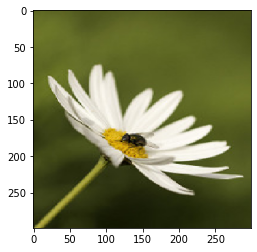

In [ ]:
from keras.preprocessing import image
import matplotlib.pyplot as plt
img = image.load_img('daisy1.jpg', 
                target_size=(299, 299))
plt.imshow(img)
plt.show()

In [ ]:
from keras.applications.inception_v3 \
    import preprocess_input, decode_predictions
import numpy as np
img = image.img_to_array(img)
img = np.expand_dims(img, axis=0)
img = preprocess_input(img)
pred = model.predict(img)
print('預測結果；\n{}'.format(decode_predictions(pred, top=3)[0]))

49152/35363 [=========================================] - 0s 0us/step
預測結果；
[('n11939491', 'daisy', 0.96036494), ('n03937543', 'pill_bottle', 0.0009715453), ('n03658185', 'letter_opener', 0.0009321727)]


In [ ]:
!pip install gradio

     |████████████████████████████████| 656 kB 4.9 MB/s 
     |████████████████████████████████| 1.1 MB 58.2 MB/s 
     |████████████████████████████████| 255 kB 65.5 MB/s 
     |████████████████████████████████| 210 kB 67.0 MB/s 
     |████████████████████████████████| 54 kB 3.1 MB/s 
     |████████████████████████████████| 2.0 MB 50.3 MB/s 
     |████████████████████████████████| 84 kB 3.0 MB/s 
     |████████████████████████████████| 53 kB 2.5 MB/s 
     |████████████████████████████████| 144 kB 62.9 MB/s 
     |████████████████████████████████| 271 kB 65.8 MB/s 
     |████████████████████████████████| 94 kB 4.2 MB/s 
     |████████████████████████████████| 10.9 MB 52.4 MB/s 
     |████████████████████████████████| 58 kB 7.3 MB/s 
     |████████████████████████████████| 79 kB 9.1 MB/s 
     |████████████████████████████████| 43 kB 2.4 MB/s 
     |████████████████████████████████| 61 kB 524 kB/s 
     |████████████████████████████████| 3.6 MB 48.1 MB/s 
     |████████████████████████

In [ ]:
import numpy as np
import gradio as gr
from keras.applications.inception_v3 \
import InceptionV3, preprocess_input, decode_predictions

model = InceptionV3()

def classify(img):
  img = np.expand_dims(img, 0)
  img = preprocess_input(img)
  pred = model.predict(img)
  depred = decode_predictions(pred)[0]
  return {depred[i][1]: float(depred[i][2]) for i in range(len(depred))}

image = gr.inputs.Image(shape=(299, 299))
label = gr.outputs.Label(num_top_classes=3, label='預測結果')
grobj = gr.Interface(fn=classify, inputs=image, 
                     outputs=label, title='Inception物件偵測')
grobj.launch()

Colab notebook detected. To show errors in colab notebook, set `debug=True` in `launch()`
Running on public URL: https://51893.gradio.app

This share link expires in 72 hours. For free permanent hosting, check out Spaces (https://huggingface.co/spaces)


(<fastapi.applications.FastAPI at 0x7f62601defd0>,
 'http://127.0.0.1:7860/',
 'https://51893.gradio.app')

## 遷移學習

### 蒐集資料：花朵資料集

In [ ]:
# 刪除整個資料夾
import shutil

removePath = r"/content/flower_photos"
shutil.rmtree(removePath)

FileNotFoundError: ignored

In [ ]:
!wget http://download.tensorflow.org/example_images/flower_photos.tgz

--2022-03-06 03:19:27--  http://download.tensorflow.org/example_images/flower_photos.tgz
Resolving download.tensorflow.org (download.tensorflow.org)... 74.125.204.128, 2404:6800:4008:c04::80
Connecting to download.tensorflow.org (download.tensorflow.org)|74.125.204.128|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228813984 (218M) [application/x-compressed-tar]
Saving to: ‘flower_photos.tgz’

flower_photos.tgz   100%[===================>] 218.21M   215MB/s    in 1.0s    

2022-03-06 03:19:28 (215 MB/s) - ‘flower_photos.tgz’ saved [228813984/228813984]



In [ ]:
!tar -xvf "flower_photos.tgz"

flower_photos/
flower_photos/roses/
flower_photos/roses/14810868100_87eb739f26_m.jpg
flower_photos/roses/1446090416_f0cad5fde4.jpg
flower_photos/roses/15319767030_e6c5602a77_m.jpg
flower_photos/roses/15032112248_30c5284e54_n.jpg
flower_photos/roses/7211616670_2d49ecb3a5_m.jpg
flower_photos/roses/15674450867_0ced942941_n.jpg
flower_photos/roses/17158274118_00ec99a23c.jpg
flower_photos/roses/14019883858_e5d2a0ec10_n.jpg
flower_photos/roses/8035908422_87220425d2_n.jpg
flower_photos/roses/14747962886_2bff6bb323_m.jpg
flower_photos/roses/4356781875_92c5cd93c0.jpg
flower_photos/roses/8524505546_b242bd4928_n.jpg
flower_photos/roses/9406573080_60eab9278e_n.jpg
flower_photos/roses/6039330368_c30ed224c4_m.jpg
flower_photos/roses/14414100710_753a36fce9.jpg
flower_photos/roses/3292434691_392071d702_n.jpg
flower_photos/roses/5273722065_c85d8543c2_m.jpg
flower_photos/roses/2215318403_06eb99176a.jpg
flower_photos/roses/172311368_49412f881b.jpg
flower_photos/roses/15255964454_0a64eb67fa.jpg
flower_pho

In [ ]:
import os, cv2, glob
    
images=[]
labels=[]
dict_labels = {"daisy":0, "dandelion":1, "roses":2, 
               "sunflowers":3, "tulips":4}
for folders in glob.glob("/content/flower_photos/*"):
    print(folders,"圖片讀取中…") 
    i = 1
    for filename in os.listdir(folders):
        label=folders.split("/")[-1]
        img=cv2.imread(os.path.join(folders,filename))
        img = cv2.resize(img,dsize=(299,299))
        if img is not None:
            images.append(img)
            labels.append(dict_labels[label])
            i += 1
            if i > 50: break
print("圖片讀取完畢!")

/content/flower_photos/tulips 圖片讀取中…
/content/flower_photos/daisy 圖片讀取中…
/content/flower_photos/roses 圖片讀取中…
/content/flower_photos/dandelion 圖片讀取中…
/content/flower_photos/sunflowers 圖片讀取中…
250
圖片讀取完畢!


### 資料預處理

In [ ]:
import numpy as np
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.inception_v3 import preprocess_input

In [ ]:
images = np.array(images)
labels = np.array(labels)

In [ ]:
print('圖片shape：{}'.format(images.shape))
print('標籤shape：{}'.format(labels.shape)) 
print('標籤值：\n{}'.format(labels))

圖片shape：(250, 299, 299, 3)
標籤shape：(250,)
標籤值：
[4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]


In [ ]:
trainX = preprocess_input(images)

In [ ]:
trainY = to_categorical(labels)

In [ ]:
print('第1個標籤值：{}'.format(labels[0]))
print('第1個one-hot值：{}'.format(trainY[0]))

第1個標籤值：4
第1個one-hot值：[0. 0. 0. 0. 1.]


### 花朵辨識卷積神經網路模型

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, \
                         Dropout, Flatten, Dense

model = Sequential()
model.add(Conv2D(filters=8, kernel_size=(5,5), padding='same', 
                 input_shape=(299, 299, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2))) 
model.add(Dropout(0.2))
model.add(Conv2D(filters=16, kernel_size=(5,5), padding='same', 
                 activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2))) 
model.add(Dropout(0.2))
model.add(Conv2D(filters=32, kernel_size=(5,5), padding='same', 
                 activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2))) 
model.add(Dropout(0.2))
model.add(Flatten())
model.add(Dropout(0.2))
model.add(Dense(units=128, activation='relu'))
model.add(Dense(units=5, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', 
              metrics=['accuracy'])
model.fit(x=trainX, y=trainY, epochs=20, batch_size=10, verbose=2)
model.save('flower_model.h5')

Epoch 1/20
25/25 - 11s - loss: 3.1691 - accuracy: 0.2040 - 11s/epoch - 430ms/step
Epoch 2/20
25/25 - 1s - loss: 1.5891 - accuracy: 0.2480 - 926ms/epoch - 37ms/step
Epoch 3/20
25/25 - 1s - loss: 1.4736 - accuracy: 0.3800 - 918ms/epoch - 37ms/step
Epoch 4/20
25/25 - 1s - loss: 1.3245 - accuracy: 0.4880 - 919ms/epoch - 37ms/step
Epoch 5/20
25/25 - 1s - loss: 1.1741 - accuracy: 0.5560 - 927ms/epoch - 37ms/step
Epoch 6/20
25/25 - 1s - loss: 0.9219 - accuracy: 0.6680 - 940ms/epoch - 38ms/step
Epoch 7/20
25/25 - 1s - loss: 0.7822 - accuracy: 0.7680 - 934ms/epoch - 37ms/step
Epoch 8/20
25/25 - 1s - loss: 0.8570 - accuracy: 0.7280 - 931ms/epoch - 37ms/step
Epoch 9/20
25/25 - 1s - loss: 0.5890 - accuracy: 0.8160 - 936ms/epoch - 37ms/step
Epoch 10/20
25/25 - 1s - loss: 0.3806 - accuracy: 0.8760 - 941ms/epoch - 38ms/step
Epoch 11/20
25/25 - 1s - loss: 0.3108 - accuracy: 0.9080 - 929ms/epoch - 37ms/step
Epoch 12/20
25/25 - 1s - loss: 0.2755 - accuracy: 0.9360 - 923ms/epoch - 37ms/step
Epoch 13/20
2

### 預測未知花朵圖片_卷積模型

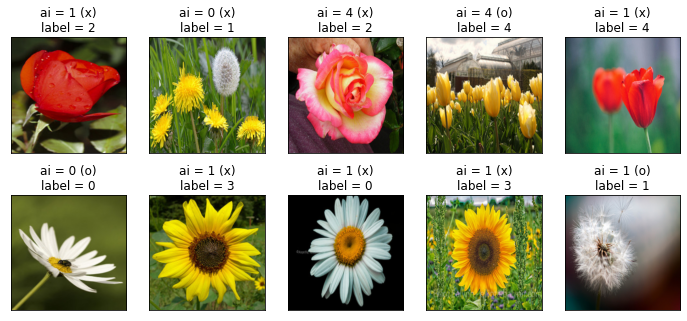

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import load_model
import glob,cv2
from keras.applications.inception_v3 import preprocess_input

def show_images_labels_predictions(images, labels, 
                                   predictions,start_id, num=10):
    plt.figure(figsize=(12, 14))
    if num>25: num=25 
    for i in range(0, num):
        ax=plt.subplot(5,5, 1+i)
        ax.imshow(images[start_id])
        if( len(predictions) > 0 ) :
            title = 'ai = ' + str(predictions[start_id])
            title += (' (o)' if predictions[start_id]==
                      labels[start_id] else ' (x)') 
            title += '\nlabel = ' + str(labels[start_id])
        else :
            title = 'label = ' + str(labels[start_id])
        ax.set_title(title,fontsize=12) 
        ax.set_xticks([]);ax.set_yticks([])        
        start_id+=1 
    plt.show()
    
files = glob.glob("/content/*.jpg" )
test_feature=[]
test_label=[]
dict_labels = {"daisy":0, "dandelion":1, "roses":2, 
               "sunflowers":3, "tulips":4}
for file in files:
    img=cv2.imread(file) 
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, dsize=(299,299))       
    test_feature.append(img)
    label=file[9:-5]
    test_label.append(dict_labels[label])
   
test_feature=np.array(test_feature) 
test_label=np.array(test_label)
test_feature_vector =test_feature.reshape(len(test_feature), 
                                          299,299,3)
test_feature_n = preprocess_input(test_feature_vector)
model = load_model('flower_model.h5')
prediction=model.predict(test_feature_n) 
prediction=np.argmax(prediction,axis=1)
show_images_labels_predictions(test_feature,test_label,
                               prediction,0,len(test_feature))

### 花朵辨識遷移學習模型

In [ ]:
from keras.applications.inception_v3 import InceptionV3
from keras.models import Sequential
from keras.layers import Dense

In [ ]:
inception = InceptionV3(weights='imagenet', 
                        include_top=False, pooling="avg")

87924736/87910968 [==============================] - 1s 0us/step


In [ ]:
inception.trainable = False

In [ ]:
model = Sequential()

In [ ]:
model.add(inception)

In [ ]:
model.add(Dense(5, activation='softmax'))

In [ ]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inception_v3 (Functional)   (None, 2048)              21802784  
                                                                 
 dense_2 (Dense)             (None, 5)                 10245     
                                                                 
Total params: 21,813,029
Trainable params: 10,245
Non-trainable params: 21,802,784
_________________________________________________________________


In [ ]:
model.compile(loss='categorical_crossentropy', 
              optimizer='adam', metrics=['accuracy'])
model.fit(trainX, trainY, batch_size=10, epochs=20)

Epoch 1/20
25/25 [==============================] - 10s 117ms/step - loss: 1.2541 - accuracy: 0.5360
Epoch 2/20
25/25 [==============================] - 3s 117ms/step - loss: 0.6348 - accuracy: 0.8280
Epoch 3/20
25/25 [==============================] - 3s 117ms/step - loss: 0.4659 - accuracy: 0.8600
Epoch 4/20
25/25 [==============================] - 3s 117ms/step - loss: 0.3636 - accuracy: 0.9000
Epoch 5/20
25/25 [==============================] - 3s 117ms/step - loss: 0.3208 - accuracy: 0.9240
Epoch 6/20
25/25 [==============================] - 3s 117ms/step - loss: 0.2344 - accuracy: 0.9640
Epoch 7/20
25/25 [==============================] - 3s 118ms/step - loss: 0.2077 - accuracy: 0.9840
Epoch 8/20
25/25 [==============================] - 3s 117ms/step - loss: 0.1689 - accuracy: 0.9920
Epoch 9/20
25/25 [==============================] - 3s 117ms/step - loss: 0.1553 - accuracy: 0.9920
Epoch 10/20
25/25 [==============================] - 3s 118ms/step - loss: 0.1377 - accuracy: 0.988

In [ ]:
model.save('transfer_model.h5')

### 預測未知花朵圖片_遷移學習模型

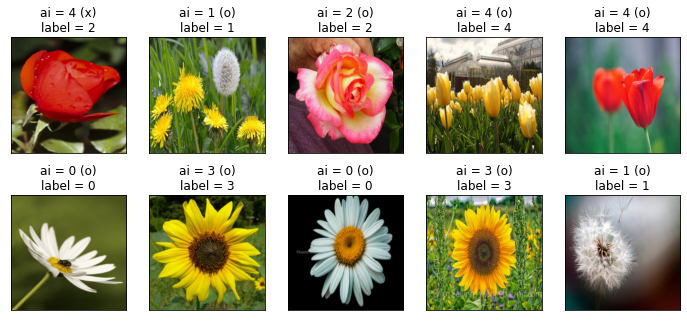

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import load_model
import glob,cv2
from keras.applications.inception_v3 import preprocess_input

def show_images_labels_predictions(images, labels, predictions,start_id, num=10):
    plt.figure(figsize=(12, 14))
    if num>25: num=25 
    for i in range(0, num):
        ax=plt.subplot(5,5, 1+i)
        ax.imshow(images[start_id])
        if( len(predictions) > 0 ) :
            title = 'ai = ' + str(predictions[start_id])
            title += (' (o)' if predictions[start_id]==labels[start_id] else ' (x)') 
            title += '\nlabel = ' + str(labels[start_id])
        else :
            title = 'label = ' + str(labels[start_id])
        ax.set_title(title,fontsize=12) 
        ax.set_xticks([]);ax.set_yticks([])        
        start_id+=1 
    plt.show()
    
files = glob.glob("/content/*.jpg" )
test_feature=[]
test_label=[]
dict_labels = {"daisy":0, "dandelion":1, "roses":2, "sunflowers":3, "tulips":4}
for file in files:
    img=cv2.imread(file) 
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, dsize=(299,299))       
    test_feature.append(img)
    label=file[9:-5]
    test_label.append(dict_labels[label])
   
test_feature=np.array(test_feature) 
test_label=np.array(test_label)
test_feature_vector =test_feature.reshape(len(test_feature), 299,299,3)
test_feature_n = preprocess_input(test_feature_vector)
model = load_model('transfer_model.h5')
prediction=model.predict(test_feature_n) 
prediction=np.argmax(prediction,axis=1)
show_images_labels_predictions(test_feature,test_label,prediction,0,len(test_feature))

### 完整遷移學習程式碼

In [ ]:
from keras.applications.inception_v3 import InceptionV3
from keras.models import Sequential
from keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from keras.applications.inception_v3 import preprocess_input
import os, cv2, glob
import numpy as np

images=[]
labels=[]
dict_labels = {"daisy":0, "dandelion":1, "roses":2, 
               "sunflowers":3, "tulips":4}
for folders in glob.glob("/content/flower_photos/*"):
    print(folders,"圖片讀取中…") 
    for filename in os.listdir(folders):
        label=folders.split("/")[-1]
        img=cv2.imread(os.path.join(folders,filename))
        img = cv2.resize(img,dsize=(299,299))
        if img is not None:
            images.append(img)
            labels.append(dict_labels[label])
print("圖片讀取完畢!")
images = np.array(images)
labels = np.array(labels)
trainX = preprocess_input(images)
trainY = to_categorical(labels)

inception = InceptionV3(weights='imagenet', 
                        include_top=False, pooling="avg")
inception.trainable = False
model = Sequential()
model.add(inception)
model.add(Dense(5, activation='softmax'))
model.compile(loss='categorical_crossentropy', 
              optimizer='adam', metrics=['accuracy'])
model.fit(trainX, trainY, batch_size=10, epochs=20)
model.save('transfer_model.h5')

/content/flower_photos/sunflowers 圖片讀取中…
/content/flower_photos/roses 圖片讀取中…
/content/flower_photos/dandelion 圖片讀取中…
/content/flower_photos/daisy 圖片讀取中…
/content/flower_photos/tulips 圖片讀取中…
圖片讀取完畢!
Epoch 1/20
367/367 [==============================] - 50s 124ms/step - loss: 0.5507 - accuracy: 0.8019
Epoch 2/20
367/367 [==============================] - 46s 125ms/step - loss: 0.3233 - accuracy: 0.8877
Epoch 3/20
367/367 [==============================] - 46s 125ms/step - loss: 0.2616 - accuracy: 0.9120
Epoch 4/20
367/367 [==============================] - 46s 125ms/step - loss: 0.2246 - accuracy: 0.9240
Epoch 5/20
367/367 [==============================] - 46s 125ms/step - loss: 0.1911 - accuracy: 0.9406
Epoch 6/20
367/367 [==============================] - 46s 125ms/step - loss: 0.1555 - accuracy: 0.9553
Epoch 7/20
367/367 [==============================] - 46s 125ms/step - loss: 0.1429 - accuracy: 0.9583
Epoch 8/20
367/367 [==============================] - 46s 125ms/step - loss: 0.13